In [1]:
# Cell 1
import os
import random
import numpy as np
import pandas as pd
import torch

# Import TabGAN generator engine
try:
    from tabgan.sampler import OriginalGenerator, GANGenerator
except ImportError:
    raise ImportError("TabGAN package not found. Install via: pip install tabgan")

# Set deterministic seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Define paths
input_path = "dataset/original/EVSE-B-PowerCombined_filtered.csv"
output_dir = "dataset/synthetic/"
os.makedirs(output_dir, exist_ok=True)

print("Environment and TabGAN dependencies successfully loaded.")

Environment and TabGAN dependencies successfully loaded.


In [2]:
# Cell 2
selected_features = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "State"]
target_col = "Attack"
cat_cols = ["State"]

# Load original dataset
df = pd.read_csv(input_path)

# Filter columns and drop missing values
columns_to_keep = selected_features + [target_col]
df_filtered = df[columns_to_keep].dropna().copy()

# Ensure string types for categorical variables
df_filtered["State"] = df_filtered["State"].astype(str)
df_filtered["Attack"] = df_filtered["Attack"].astype(str)

print(f"Data loaded. Shape: {df_filtered.shape}")
print(df_filtered.head())

# Matches exact hyperparameters from Script 1
params = {
    "name": "experiment_v2",
    "gen_x_times": 0.75,
    "pregeneration_frac": 1,
    "is_post_process": True,
    "bot_filter_quantile": 0.001,
    "top_filter_quantile": 0.9999,
    "use_adversarial": False,
    "batch_size": 300,
    "patience": 25,
    "epochs": 100,  # Fixed: Restored to 100 epochs
}

Data loaded. Shape: (49017, 6)
   shunt_voltage  bus_voltage_V  current_mA  power_mW State     Attack
0            978          5.165        1027      5300  idle  syn-flood
1            872          5.161        1009      4980  idle  syn-flood
2           1017          5.165        1029      5300  idle  syn-flood
3            930          5.161        1005      5180  idle  syn-flood
4            958          5.165        1034      5180  idle  syn-flood


In [6]:
# Cell 3 (revised with pickle-based saving)
# Target sample counts per attack class
target_counts = {
    "none": 10053,
    "Backdoor": 14796,
    "syn-flood": 9463
}

synthetic_dfs = []
saved_generators = {}

# Train and generate synthetic tabular samples per class
for attack_class, target_num in target_counts.items():
    print(f"\n--- Processing TabGAN for Attack class: '{attack_class}' ---")

    # Filter class-specific subset
    class_df = df_filtered[df_filtered[target_col] == attack_class].copy().reset_index(drop=True)

    if len(class_df) < 10:
        print(f"Skipping class '{attack_class}' (insufficient rows).")
        continue

    # Encode dummy target for single-class generation
    class_df["Attack_enc"] = 0

    X_train = class_df[selected_features].copy()
    y_train = class_df[["Attack_enc"]].copy()
    X_test = X_train.copy()

    # Initialize TabGAN Generator
    new_generator = GANGenerator(
        gen_x_times=params["gen_x_times"],
        cat_cols=cat_cols,
        pregeneration_frac=params["pregeneration_frac"],
        is_post_process=params["is_post_process"],
        bot_filter_quantile=params["bot_filter_quantile"],
        top_filter_quantile=params["top_filter_quantile"],
        gen_params={
            "batch_size": params["batch_size"],
            "patience": params["patience"],
            "epochs": params["epochs"]
        }
    )

    # Generate synthetic features
    syn_x, syn_y = new_generator.generate_data_pipe(
        train_df=X_train,
        target=y_train,
        test_df=X_test,
        deep_copy=True,
        only_adversarial=False,
        use_adversarial=params["use_adversarial"]
    )

    # === Save the entire GANGenerator object with pickle ===
    import pickle
    
    generator_path = f"models/tabgan_generator_{attack_class}.pkl"
    os.makedirs("models", exist_ok=True)
    
    with open(generator_path, 'wb') as f:
        pickle.dump(new_generator, f)
    
    saved_generators[attack_class] = generator_path
    print(f"✓ Saved generator for '{attack_class}' to: {generator_path}")

    syn_df = pd.concat(
        [syn_x.reset_index(drop=True), syn_y.reset_index(drop=True)],
        axis=1
    )

    if "Attack_enc" not in syn_df.columns and syn_df.shape[1] == len(selected_features) + 1:
        syn_df.columns = selected_features + ["Attack_enc"]

    # Re-assign original class label
    syn_df[target_col] = attack_class
    syn_df = syn_df[selected_features + [target_col]].copy()

    # Sample precisely to requested target size
    syn_df = syn_df.sample(
        n=target_num,
        replace=len(syn_df) < target_num,
        random_state=SEED
    ).reset_index(drop=True)

    synthetic_dfs.append(syn_df)

print("\nTabGAN per-class generation complete.")
print(f"\nSaved generators: {saved_generators}")


--- Processing TabGAN for Attack class: 'none' ---


Fitting CTGAN transformers for each column:   0%|          | 0/6 [00:00<?, ?it/s]

Training CTGAN, epochs::   0%|          | 0/100 [00:00<?, ?it/s]

✓ Saved generator for 'none' to: models/tabgan_generator_none.pkl

--- Processing TabGAN for Attack class: 'Backdoor' ---


Fitting CTGAN transformers for each column:   0%|          | 0/6 [00:00<?, ?it/s]

Training CTGAN, epochs::   0%|          | 0/100 [00:00<?, ?it/s]

✓ Saved generator for 'Backdoor' to: models/tabgan_generator_Backdoor.pkl

--- Processing TabGAN for Attack class: 'syn-flood' ---


Fitting CTGAN transformers for each column:   0%|          | 0/6 [00:00<?, ?it/s]

Training CTGAN, epochs::   0%|          | 0/100 [00:00<?, ?it/s]

✓ Saved generator for 'syn-flood' to: models/tabgan_generator_syn-flood.pkl

TabGAN per-class generation complete.

Saved generators: {'none': 'models/tabgan_generator_none.pkl', 'Backdoor': 'models/tabgan_generator_Backdoor.pkl', 'syn-flood': 'models/tabgan_generator_syn-flood.pkl'}


In [4]:
# Cell 4
# Combine generated class dataframes and shuffle
final_tabgan_synthetic_df = pd.concat(synthetic_dfs, ignore_index=True)
final_tabgan_synthetic_df = final_tabgan_synthetic_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Save to output path
output_file = os.path.join(output_dir, "tabgan_synthetic_dataset.csv")
final_tabgan_synthetic_df.to_csv(output_file, index=False)

print(f"TabGAN synthetic dataset saved to: {output_file}")
print("\nGenerated Target Class Distributions:")
print(final_tabgan_synthetic_df[target_col].value_counts())

print("\nDataset Sample Preview:")
print(final_tabgan_synthetic_df.head())

TabGAN synthetic dataset saved to: dataset/synthetic/tabgan_synthetic_dataset.csv

Generated Target Class Distributions:
Attack
Backdoor     14796
none         10053
syn-flood     9463
Name: count, dtype: int64

Dataset Sample Preview:
   shunt_voltage  bus_voltage_V  current_mA  power_mW     State     Attack
0            549       5.197000         754      3300  charging   Backdoor
1            967       5.161000         941      4840      idle  syn-flood
2            860       5.188081         773      3166  charging       none
3            533       5.197000         561      2920  charging   Backdoor
4            891       5.161727         682      4677      idle  syn-flood


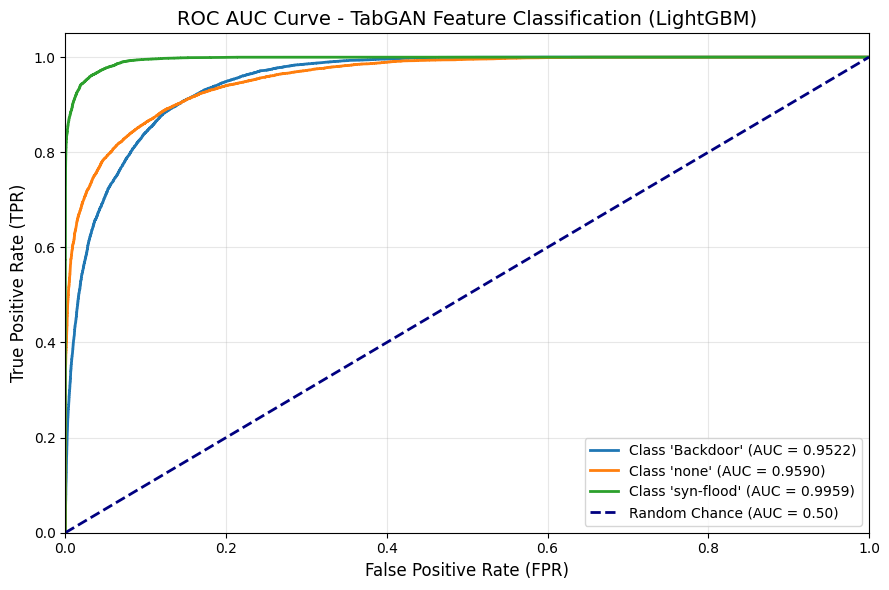

In [5]:
# Cell 5: Evaluate TabGAN Feature Discriminative Power with Multi-Class ROC AUC

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import auc, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

# 1. Prepare features and target encoding
X = pd.get_dummies(
    df_filtered[selected_features], columns=cat_cols, drop_first=True
)
y = df_filtered[target_col].values

classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)
n_classes = len(classes)

# 2. Set up Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_score = np.zeros((len(df_filtered), n_classes))

# 3. Train LightGBM classifier to obtain predicted probabilities across folds
for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train = y[train_idx]

    clf = LGBMClassifier(
        n_estimators=100, learning_rate=0.05, random_state=SEED, verbose=-1
    )
    clf.fit(X_train, y_train)

    # Store class probability predictions
    y_score[val_idx] = clf.predict_proba(X_val)

# 4. Compute ROC Curve and AUC score for each class (One-vs-Rest)
plt.figure(figsize=(9, 6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr, lw=2, label=f"Class '{class_name}' (AUC = {roc_auc:.4f})"
    )

# Plot random chance reference line
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--",
    label="Random Chance (AUC = 0.50)",
)

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title(
    "ROC AUC Curve - TabGAN Feature Classification (LightGBM)", fontsize=14
)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()